In [150]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import cKDTree
from scipy.linalg import solve
from scipy.optimize import least_squares
from scipy.spatial.distance import pdist
from scipy.sparse import lil_matrix, csc_matrix
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import splu
import scipy as sp

In [227]:
mesh = loadmat("mesh_claude_single_backstep.mat")
L = 0.1/0.0101
AR = L
H = 1
Re = 389    
h0 = 0.04
step = 0.0049/0.0101
w_obstacle = 1.9802
#Tengo los nodos como pressure y las presiones como nodes y esto SI es 
#correcto ya que en matlab se crean mas puntos de presión que de velocidad
#Así que solo cambié la definición
#loadmat("mesh_backstep.mat")
nodes = mesh["pressure"]
triangles = mesh["t"] - 1       # MATLAB -> Python indexing
pressure = mesh["p"] 


tree = cKDTree(nodes)
d, _ = tree.query(nodes, k=2)          # k=2: self (dist 0) + nearest neighbor
nn_dist = d[:, 1]
print("mean:", nn_dist.mean(), "min:", nn_dist.min())

#Parameters for differential operators close and far from boundaries
k = 28
q = 3
m = 7
k_near = 28
q_near = 3
m_near = 7




mean: 0.0250186620943027 min: 0.019220936594824264


In [228]:
#nodes_out_of_the_domain = ((np.abs(nodes[:,0]) < 1/8 - 1e-3) & (nodes[:,1]<step - min_dist_v))
#out_u = np.where(nodes_out_of_the_domain)[0]
nodes_u = nodes.copy()#[~nodes_out_of_the_domain]

boundary_inlet = np.where(
    (np.abs(nodes_u[:,0] - nodes_u[:,0].min() )< 1e-12) & (nodes_u[:,1] > step + 1e-12 ) & (nodes_u[:,1] < nodes_u[:,1].max())
)[0]
boundary_outlet = np.where(
    (np.abs(nodes_u[:,0] - nodes_u[:,0].max()) < 1e-12)  & (nodes_u[:,1] > 0) & (nodes_u[:,1] < 1)
)[0]
boundary_walls_up = np.where(
    
    (np.abs(nodes_u[:,1] - 1 )<= 1e-8) 
)[0]
boundary_walls_down = np.where(
    (np.abs(nodes_u[:,1]) < 1e-6 )
)[0]
boundary_walls_right = np.where( (np.abs(nodes_u[:,0]- (w_obstacle))<1e-12)  
                                 & (nodes_u[:,1] < step) & (nodes_u[:,1] > 0)  )[0]



boundary_wall_entrance = np.where(
    (np.abs(nodes_u[:,1] - (step)) <=1e-10) & ((nodes_u[:,0])<= nodes_u[boundary_walls_right][0,0]   ) & (nodes_u[:,1]>=step-h0/100) & ((nodes_u[:,0])> 0  )
)[0]

border_nodes = np.concatenate((boundary_inlet
                               ,boundary_outlet
                               ,boundary_walls_down,boundary_walls_up,boundary_walls_right,boundary_wall_entrance))
mask = np.ones(len(nodes_u), dtype=bool)
mask[border_nodes] = False
interior_nd = np.where(mask)[0]
boundary_wall_entrance.shape[0]

41

In [229]:
centers_p = pressure.copy()

p_wall_up = np.where(np.abs(centers_p[:,1] - H)<= 1e-9)[0]
p_wall_down = np.where(np.abs(centers_p[:,1])<= 1e-10)[0]
p_inlet = np.where((np.abs(centers_p[:,0]- centers_p[:,0].min())<=1e-12) & (centers_p[:,1] < centers_p[p_wall_up][0,1]) & (centers_p[:,1] > step + 1e-12))[0]
p_outlet = np.where((np.abs(centers_p[:,0]-centers_p[:,0].max())<=1e-12) & (centers_p[:,1] < centers_p[p_wall_up][0,1]) & (centers_p[:,1] > centers_p[p_wall_down][0,1]))[0]
#p_dirichlet = np.where((centers_p == centers_p[1,1]))[0]

p_wall_entrance = np.where( (np.abs(centers_p[:,1] - nodes_u[boundary_wall_entrance][1,1])<= 1e-12)
                           &( centers_p[:,0]<= nodes_u[boundary_walls_right][0,0]) & 
                           ( centers_p[:,0]>= 0)
                           )[0]


p_wall_right = np.where((np.abs(centers_p[:,0] - nodes_u[boundary_walls_right][0,0])<=1e-10 )
                       & ((centers_p[:,1]) < centers_p[p_wall_entrance][0,1]) & (centers_p[:,1]>1e-12)
                       )[0]



mask = np.ones(len(centers_p), dtype=bool)
mask[ np.concatenate((p_wall_right,p_wall_entrance,
                      p_wall_up,p_wall_down
                      ,p_inlet,p_outlet
                      ))
      
                     ] = False



p_interior = np.where(mask)[0]
p_wall_down.shape[0] + p_wall_up.shape[0] + p_wall_entrance.shape[0] + p_wall_right.shape[0] + p_inlet.shape[0] + p_outlet.shape[0] + p_interior.shape[0] == centers_p.shape[0]


True

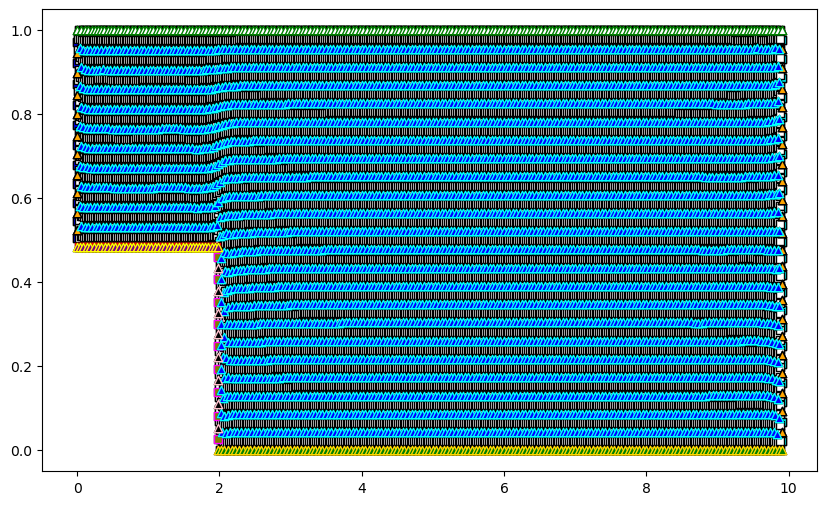

In [230]:
plt.figure(figsize=(10,6))
plt.scatter(nodes_u[:,0], nodes_u[:,1],
            marker = "s", color='red',edgecolor = "black")

plt.scatter(nodes_u[boundary_inlet][:,0], nodes_u[boundary_inlet][:,1],
            marker = "s", color='blue',edgecolor = "black")
plt.scatter(nodes_u[boundary_outlet][:,0], nodes_u[boundary_outlet][:,1],
            marker = "s", color='cyan',edgecolor = "black")

plt.scatter(nodes_u[boundary_walls_up][:,0], nodes_u[boundary_walls_up][:,1],
            marker = "s", color='green',edgecolor = "black")
plt.scatter(nodes_u[boundary_walls_down][:,0], nodes_u[boundary_walls_down][:,1],
            marker = "s", color='yellow',edgecolor = "black")

plt.scatter(nodes_u[interior_nd][:,0], nodes_u[interior_nd][:,1],
            marker = "s", color='white',edgecolor = "black")
plt.scatter(nodes_u[boundary_walls_right][:,0], nodes_u[boundary_walls_right][:,1],
            marker = "s", color = "olive",edgecolor = "magenta")

plt.scatter(nodes_u[boundary_wall_entrance][:,0], nodes_u[boundary_wall_entrance][:,1],
            marker = "s", color = "olive",edgecolor = "red")

plt.scatter(centers_p[:,0], centers_p[:,1],
            marker = "^", color='red',edgecolor = "black")
plt.scatter(centers_p[p_inlet][:,0], centers_p[p_inlet][:,1],
            marker = "^", color='orange',edgecolor = "black")
plt.scatter(centers_p[p_outlet][:,0], centers_p[p_outlet][:,1],
            marker = "^", color='orange',edgecolor = "black")
plt.scatter(centers_p[p_interior][:,0], centers_p[p_interior][:,1],
            marker = "^", color='blue',edgecolor = "cyan")

plt.scatter(centers_p[p_wall_down][:,0], centers_p[p_wall_down][:,1],
            marker = "^", color='green',edgecolor = "gold")
plt.scatter(centers_p[p_wall_up][:,0], centers_p[p_wall_up][:,1],
            marker = "^", color='white',edgecolor = "green")

plt.scatter(centers_p[p_wall_right][:,0], centers_p[p_wall_right][:,1],
            marker = "^", color='black',edgecolor = "pink")
plt.scatter(centers_p[p_wall_entrance][:,0], centers_p[p_wall_entrance][:,1],
            marker = "^", color='purple',edgecolor = "yellow")
    


In [231]:
N_u = nodes_u.shape[0]
N_p = centers_p.shape[0]
# --------------------------------------------------
# 3. RBF definition (PHS r^3)
# --------------------------------------------------
#Types: MQ: Multicuadrics, even_TPS,odd_TPS, Gaussian
Type = 'odd_TPS'

if Type == 'even_TPS':
    a = 3
    print("TPS")
    def phi(r):
        result = np.zeros_like(r)
        result[r != 0] = r[r!= 0]**(2*a) * np.log(r[r!= 0])
        return result#r**(2*a)#
    def laplacian_phi(r):
        # Laplacian of r^(2*a) in 2D: Δ(r^(2*a)) = 4*a*(2*a-2)*r^(2*a-4)
        result = np.zeros_like(r)
        result[r != 0] = 4*a*r[r!= 0]**(2*a-2)*(a*np.log(r[r!=0]) + 1)
        return result# 4*a**2*r**(2*a-2)#
    def phi_dx(r,x,xc):
        result = np.zeros_like(r)
        result[r!=0] = r[r!=0]**(2*a-2)*(2*a*np.log(r[r!=0]) + 1)*(x-xc)[r!=0]
        return result#2*a*r**(2*a-2)*(x-xc)#
    def phi_dy(r,y,yc):
        result = np.zeros_like(r)
        result[r!=0] = r[r!=0]**(2*a-2)*(2*a*np.log(r[r!=0]) + 1)*(y-yc)[r!=0]
        return result#2*a*r**(2*a-2)*(y-yc)#
    def phi_dx2(r,x,xc):
        result= np.zeros_like(r)
        result[r!=0] = (r[r!=0]**(2*a-2)*(2*a*np.log(r[r!=0]) + 1) + r[r!=0]**(2*a-4)*((2*a-2)*(2*a*np.log(r[r!=0]) + 1) +2*a))*(x - xc)[r!=0]**2
        return result#2*a*(r**(2*a-2) + (x-xc)**2 * (2*a-2)*r**(2*a-4))#   
    def phi_dy2(r,y,yc):
        result= np.zeros_like(r)
        result[r!=0] = (r[r!=0]**(2*a-2)*(2*a*np.log(r[r!=0]) + 1) + r[r!=0]**(2*a-4)*((2*a-2)*(2*a*np.log(r[r!=0]) + 1) +2*a))*(y - yc)[r!=0]**2
        return result#2*a*(r**(2*a-2) + (y-yc)**2 * (2*a-2)*r**(2*a-4))# 
elif Type == 'odd_TPS':
    def _phi(r,a):
        return r**(a)
    def laplacian_phi(r,a):
        return  a**2*r**(a-2)#
    def _phi_dx(r,x,xc,a):
        return a*r**(a-2)*(x-xc)#
    def _phi_dy(r,y,yc,a):
        return a*r**(a-2)*(y-yc)#
    def _phi_dx2(r,x,xc,a):
        return a*(r**(a-2) + (x-xc)**2 * (a-2)*r**(a-4))#   
    def _phi_dy2(r,y,yc,a):
        return a*(r**(a-2) + (y-yc)**2 * (a-2)*r**(a-4))# 

elif Type == 'Gaussian':
    print("Gaussian")
    eps = 8.133652754717849 #0.3*( np.abs(x_nd[1]-x_nd[0])**2 + np.abs(y_nd[1]-y_nd[0])**2)**0.5# 0.32/( np.abs(x_nd[1]-x_nd[0]) + np.abs(y_nd[1]-y_nd[0]))/2 #1.5#5.0
    def phi(r):
        return np.exp(-(eps*r)**2)
    def laplacian_phi(r):
        return 4*eps**2*(eps**2*r**2 - 1)*np.exp(-(eps*r)**2)
    def phi_dx(r,x,xc):
        return -2*eps**2*np.exp(-eps**2*r**2)*(x-xc)
    def phi_dx2(r,x,xc):
        return -2*eps**2*(-2*eps**2*np.exp(-eps**2*r**2)*(x-xc)**2 +  np.exp(-eps**2*r**2))
    def phi_dy2(r,y,yc):
        return -2*eps**2*(-2*eps**2*np.exp(-eps**2*r**2)*(y-yc)**2 +  np.exp(-eps**2*r**2))
    def phi_dy(r,y,yc):
        return -2*eps**2*np.exp(-eps**2*r**2)*(y-yc)
elif Type == 'MQ':
    print("Multiquadrics")
    eps = 0.5
    def phi(r):
        return np.sqrt(r**2 + eps**2)
    def phi_dx(r,x,xc):
        return (x-xc)/(np.sqrt(r**2 + eps**2))
    def phi_dy(r,y,yc):
        return (y-yc)/(np.sqrt(r**2 + eps**2))
    def phi_dx2(r,x,xc):
        return (r**2-(x-xc)**2 +eps**2)/(r**2+eps**2)**(3/2)
    def phi_dy2(r,y,yc):
        return (r**2-(y-yc)**2 +eps**2)/(r**2+eps**2)**(3/2)
    def laplacian_phi(r):
        return (r**2 + 2*eps**2)/(r**2+eps**2)**(3/2)

In [232]:
def _poly_terms(d):
    """List of (i, j) exponent pairs for all monomials x^i y^j with i+j<=d,
    ordered to match your existing column layout (by increasing total degree,
    then by decreasing power of x within each degree)."""
    terms = []
    for deg in range(d + 1):
        for i in range(deg, -1, -1):
            j = deg - i
            terms.append((i, j))
    return terms  # length (d+1)(d+2)/2
 
def _poly_block(stencil, d):
    terms = _poly_terms(d)
    k = stencil.shape[0]
    ss = len(terms)
    P = np.zeros((k, ss))
    for col, (i, j) in enumerate(terms):
        P[:, col] = stencil[:, 0] ** i * stencil[:, 1] ** j
    return P, terms
 
def _poly_rhs(terms, kind):
    """RHS row(s) enforcing the polynomial-reproduction constraints for eq. (7)
    in the paper: L(P_i)(x0)=0 vanishes automatically for constant/x/y terms
    except the one matching `kind` ('dx' -> d/dx(x)=1, 'dy' -> d/dy(y)=1)."""
    ss = len(terms)
    rhs = np.zeros(ss)
    for col, (i, j) in enumerate(terms):
        if kind == "dx" and i == 1 and j == 0:
            rhs[col] = 1.0
        elif kind == "dy" and i == 0 and j == 1:
            rhs[col] = 1.0
        elif kind == "lap" and i == 2 and j == 0:
            rhs[col] = 2.0
        elif kind == "lap" and i == 0 and j == 2:
            rhs[col] = 2.0
    return rhs
 
 
# ---------------------------------------------------------------------------
# Main builder
# ---------------------------------------------------------------------------
def build_diff_ops(eval_pts, source_pts, near_mask,
                    stencil_size, m, poly_degree,
                    stencil_size_near, m_near, poly_degree_near):
    """
    Build Dx, Dy, DL (Laplacian) sparse operators mapping source_pts -> eval_pts.
 
    eval_pts   : (N_eval, 2) array -- where the derivative is evaluated
    source_pts : (N_src, 2) array  -- pool the stencil is drawn from
    near_mask  : (N_eval,) bool    -- True where eval point uses the "near"
                 (typically lower-order) parameters instead of the bulk ones
    stencil_size, m, poly_degree             : bulk-region parameters
    stencil_size_near, m_near, poly_degree_near : near-boundary parameters
 
    Returns (Dx, Dy, DL) as scipy.sparse csr_matrix, shape (N_eval, N_src).
    """
    N_eval = eval_pts.shape[0]
    N_src = source_pts.shape[0]
    near_mask = np.asarray(near_mask, dtype=bool).ravel()
    assert near_mask.shape[0] == N_eval
 
    tree = cKDTree(source_pts)
 
    Dx = lil_matrix((N_eval, N_src))
    Dy = lil_matrix((N_eval, N_src))
    DL = lil_matrix((N_eval, N_src))
 
    for i in range(N_eval):
        is_near = near_mask[i]
        k = stencil_size_near if is_near else stencil_size
        a = m_near if is_near else m
        d = poly_degree_near if is_near else poly_degree
 
        xi = eval_pts[i]
        dist, idx = tree.query(xi, k=k)
        stencil = source_pts[idx] - xi
        scale = dist.max()
        if scale == 0:
            scale = 1.0
        stencil = stencil / scale
 
        DM = np.sqrt((stencil[:, 0].reshape(-1, 1) - stencil[:, 0].reshape(1, -1)) ** 2
                     + (stencil[:, 1].reshape(-1, 1) - stencil[:, 1].reshape(1, -1)) ** 2)
        Phi = _phi(DM, a)
 
        P, terms = _poly_block(stencil, d)
        ss = P.shape[1]
        A = np.block([[Phi, P], [P.T, np.zeros((ss, ss))]])
        A = (A + A.T) / 2  # numerical symmetry, matches reference code's solve_rbf_weights
 
        r = np.linalg.norm(stencil, axis=1)
 
        rhs_x = np.zeros(k + ss)
        rhs_x[:k] = _phi_dx(r, 0, stencil[:, 0], a)
        rhs_x[k:] = _poly_rhs(terms, "dx")
 
        rhs_y = np.zeros(k + ss)
        rhs_y[:k] = _phi_dy(r, 0, stencil[:, 1], a)
        rhs_y[k:] = _poly_rhs(terms, "dy")
 
        rhs_L = np.zeros(k + ss)
        rhs_L[:k] = _phi_dx2(r, 0, stencil[:, 0], a) + _phi_dy2(r, 0, stencil[:, 1], a)
        rhs_L[k:] = _poly_rhs(terms, "lap")
 
        w = np.linalg.solve(A, np.column_stack([rhs_x, rhs_y, rhs_L]))
 
        Dx[i, idx] = w[:k, 0] / scale
        Dy[i, idx] = w[:k, 1] / scale
        DL[i, idx] = w[:k, 2] / scale ** 2
 
    return Dx.tocsr(), Dy.tocsr(), DL.tocsr()
 
 
# ---------------------------------------------------------------------------
# Helper: build the near-boundary mask the way build_velocity_operators.m
# does it -- distance to the nearest wall/step-face below a threshold.
# Call once per grid (V-grid, P-grid) and reuse across all four build_diff_ops
# calls that use that grid as the EVAL grid.
# ---------------------------------------------------------------------------
def near_geometry_mask(pts, H, step, xo2, AR, wall_band, corner_band):
    """
    pts        : (N,2) array of node coordinates
    H          : channel height (1.0)
    step       : step height (H_obstacle)
    xo2        : step x-location (W_obstacle)
    AR         : domain length
    wall_band  : distance threshold from top/bottom walls counted as "near"
    corner_band: distance threshold from the reentrant corner (xo2, step)
                 counted as "near" (usually tighter/more local than wall_band)
 
    Returns a bool mask, True where the point should use the near-boundary
    (lower-order) stencil parameters.
    """
    x, y = pts[:, 0], pts[:, 1]
 
    near_top_bottom = (y < wall_band) | (y > H - wall_band)
 
    # near the step's two faces (vertical x=xo2 for 0<y<step, horizontal
    # y=step for 0<x<xo2) -- same wall_band, since these are also solid walls
    near_step_face = ((np.abs(x - xo2) < wall_band) & (y < step)) | \
                     ((np.abs(y - step) < wall_band) & (x < xo2))
 
    # extra-tight ring right around the reentrant corner itself (the
    # geometric singularity) -- this can get its own, even lower order
    # if you want a third tier; for now it's folded into near_step_face
    near_corner = np.hypot(x - xo2, y - step) < corner_band
 
    return near_top_bottom | near_step_face | near_corner
def boundary_derivative_rows(bidx, centers_p, p_interior, stencil_size=20):
    """dp/dx and dp/dy rows at the boundary nodes `bidx`.

    The stencil is the boundary node ITSELF plus the (stencil_size - 1) nearest
    INTERIOR pressure nodes.  No other boundary node ever enters the stencil,
    so the Neumann rows stop referencing each other.
            
    Returns (Dx_b, Dy_b), each sparse of shape (len(bidx), N_p).
    """
    ss = 10                                    # number of polynomial terms, q = 3
    bidx = np.atleast_1d(np.asarray(bidx)).ravel()
    p_interior = np.asarray(p_interior).ravel()

    tree_int = cKDTree(centers_p[p_interior])
    xi = centers_p[bidx]
    _, loc = tree_int.query(xi, k=stencil_size - 1)
    idx = np.concatenate([bidx[:, None], p_interior[loc]], axis=1)   # self first
    
    
    Wx = np.zeros((len(bidx), stencil_size))
    Wy = np.zeros((len(bidx), stencil_size))

    for row in range(len(bidx)):
        stencil = centers_p[idx[row]] - xi[row]
        stabilization_Scale = np.linalg.norm(stencil, axis=1).max()
        stencil = stencil / stabilization_Scale

        DM = np.sqrt((stencil[:, 0].reshape(-1, 1) - stencil[:, 0].reshape(1, -1))**2
                   + (stencil[:, 1].reshape(-1, 1) - stencil[:, 1].reshape(1, -1))**2)

        P = np.zeros((stencil_size, ss))
        P[:, 0] = 1
        P[:, 1] = stencil[:, 0]
        P[:, 2] = stencil[:, 1]
        P[:, 3] = stencil[:, 0]**2
        P[:, 4] = stencil[:, 1]**2
        P[:, 5] = stencil[:, 0] * stencil[:, 1]
        P[:, 6] = stencil[:, 0]**3
        P[:, 7] = stencil[:, 1]**3
        P[:, 8] = stencil[:, 0]**2 * stencil[:, 1]
        P[:, 9] = stencil[:, 0] * stencil[:, 1]**2

        A = np.block([[_phi(DM,7), P],
                      [P.T, np.zeros((ss, ss))]])

        r = np.linalg.norm(stencil, axis=1)

        rhs_x = np.zeros(stencil_size + ss)
        rhs_x[:stencil_size] = _phi_dx(r, 0, stencil[:, 0],7)
        rhs_x[stencil_size + 1] = 1                      # d/dx of the 'x' column

        rhs_y = np.zeros(stencil_size + ss)
        rhs_y[:stencil_size] = _phi_dy(r, 0, stencil[:, 1],7)
        rhs_y[stencil_size + 2] = 1                      # d/dy of the 'y' column

        Wx[row] = np.linalg.solve(A, rhs_x)[:stencil_size] / stabilization_Scale
        Wy[row] = np.linalg.solve(A, rhs_y)[:stencil_size] / stabilization_Scale

    rows = np.repeat(np.arange(len(bidx)), stencil_size)
    Dx_b = csr_matrix((Wx.ravel(), (rows, idx.ravel())), shape=(len(bidx), len(centers_p)))
    Dy_b = csr_matrix((Wy.ravel(), (rows, idx.ravel())), shape=(len(bidx), len(centers_p)))
    return Dx_b, Dy_b

In [233]:
near_mask_u = near_geometry_mask(nodes_u,H,step,nodes_u[boundary_walls_right][0,0],AR,0.5*h0,1.1*h0)
near_mask_p = near_geometry_mask(centers_p,H,step,centers_p[p_wall_right][0,0],AR,0.5*h0,1.1*h0)

In [234]:
Dx_UU, Dy_UU, DL_UU = build_diff_ops(nodes_u,  nodes_u,  near_mask_u, 28, 7, 3, k_near, m_near, q_near)
Dx_PU, Dy_PU, DL_PU = build_diff_ops(centers_p, nodes_u,  near_mask_p, 28, 7, 3, k_near, m_near, q_near)
Dx_UP, Dy_UP, DL_UP = build_diff_ops(nodes_u,  centers_p, near_mask_u, 28, 7, 3, k_near, m_near, q_near)
Dx_PP, Dy_PP, DL_PP = build_diff_ops(centers_p, centers_p, near_mask_p, 28, 7, 3, k_near, m_near, q_near)

In [235]:
BND_STENCIL = 20

# each call returns BOTH derivatives for that set; keep the one matching the normal
Dx_b_inlet,       _              = boundary_derivative_rows(p_inlet,         centers_p, p_interior, BND_STENCIL)
Dx_b_outlet,      _              = boundary_derivative_rows(p_outlet,        centers_p, p_interior, BND_STENCIL)
Dx_b_wall_right,  _              = boundary_derivative_rows(p_wall_right,    centers_p, p_interior, BND_STENCIL)
_,                Dy_b_wall_up   = boundary_derivative_rows(p_wall_up,       centers_p, p_interior, BND_STENCIL)
_,                Dy_b_wall_down = boundary_derivative_rows(p_wall_down,     centers_p, p_interior, BND_STENCIL)
_,                Dy_b_entrance  = boundary_derivative_rows(p_wall_entrance, centers_p, p_interior, BND_STENCIL)

In [236]:

from mesh_audit import audit_mesh
sets = dict(top=p_wall_up, bottom=p_wall_down, inlet=p_inlet, outlet=p_outlet,
            interior=p_interior,
            extra_x=p_wall_right,  # n = ±x
            extra_y=p_wall_entrance)  


 
audit_mesh(centers_p, nodes_u, p_sets=sets,
           Dx_UU=Dx_UU, Dy_UU=Dy_UU, DL_UU=DL_UU,
           Dx_PU=Dx_PU, Dy_PU=Dy_PU, Dx_UP=Dx_UP, Dy_UP=Dy_UP,
           Dx_PP=Dx_PP, Dy_PP=Dy_PP, DL_PP=DL_PP)


      check                                                                 value
----------------------------------------------------------------------------------------
  ok  rows of V-nodes across the height                                     39.9
  ok  fraction of the height a 28-node stencil spans                        0.14
  ok  min/median V spacing (slivers)                                        0.77
  ok  min/median P spacing (slivers)                                        0.77
  ok  worst neighbour size jump (grading smoothness)                        1.18
  ok  N_V / N_P  (edge midpoints -> ~3; centroids -> ~2)                    2.90
  ok  P-nodes with two BCs                                                  0
  ok  P-nodes with no equation                                              0
  ok  Dx_UU @ 1        (must be 0)                                          3.0e-13
  ok  Dx_UU @ x  - 1   (must be 0)                                          3.0e-12
  ok  DL_UU @ x^2 -

In [237]:
DL_UU_interior = DL_UU[interior_nd].copy()

Dx_UU_interior = Dx_UU[interior_nd].copy()
Dy_UU_interior = Dy_UU[interior_nd].copy()
Dx_UU_outlet = Dx_UU[boundary_outlet].copy()


Dx_UP_interior = Dx_UP[interior_nd].copy()
Dy_UP_interior = Dy_UP[interior_nd].copy()
Dx_PU_interior = Dx_PU[p_interior].copy()
Dy_PU_interior = Dy_PU[p_interior].copy()

DL_PU_interior = DL_PU[p_interior].copy()
Dx_PP_interior = Dx_PP[p_interior].copy()

Dx_PU_interior = Dx_PU[p_interior]
Dy_PU_interior = Dy_PU[p_interior]




Dy_PP_wall_down = Dy_PP[p_wall_down].copy()
Dy_PP_wall_up = Dy_PP[p_wall_up].copy()

Dx_PP_wall_right = Dx_PP[p_wall_right].copy()
Dy_PP_wall_entrance = Dy_PP[p_wall_entrance].copy()




In [238]:
print(np.intersect1d(p_interior, p_wall_up))
print(np.intersect1d(p_interior, p_wall_right))
print(np.intersect1d(p_interior, p_inlet))
print(np.intersect1d(p_wall_up, p_inlet))
print(np.intersect1d(p_wall_down, p_inlet))
print(np.intersect1d(p_interior, p_wall_down))
print(np.intersect1d(p_interior, p_wall_entrance))
print(np.intersect1d(p_wall_right, p_wall_entrance))
print(np.intersect1d(p_inlet, p_wall_entrance))
print(np.intersect1d(p_wall_right, p_wall_down))
print(np.intersect1d(boundary_inlet, boundary_walls_up))
print(np.intersect1d(boundary_walls_right, boundary_wall_entrance))
print(np.intersect1d(boundary_walls_right, boundary_walls_down))
print(np.intersect1d(boundary_inlet, boundary_walls_down))
print(np.intersect1d(boundary_walls_up, boundary_walls_down))
print(np.intersect1d(p_wall_up, p_wall_down))

[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]


In [239]:
print('step =', step, '  mesh step top =', nodes_u[boundary_wall_entrance,1].max())
#print('u_in peak %.4f  min %.4f' % (u_in.max(), u_in.min()))
print('V counts:', [len(s) for s in (boundary_inlet,boundary_outlet,boundary_walls_up,
      boundary_walls_down,boundary_walls_right,boundary_wall_entrance,interior_nd)],
      '-> total', N_u)
print('P counts:', [len(s) for s in (p_inlet,p_outlet,p_wall_up,p_wall_down,
      p_wall_right,p_wall_entrance,p_interior)], '-> total', N_p)

step = 0.48514851485148514   mesh step top = 0.48514851485148514
V counts: [11, 23, 199, 158, 9, 41, 11976] -> total 12417
P counts: [10, 22, 200, 159, 8, 42, 3846] -> total 4287


In [240]:
from scipy.linalg import lu_factor, lu_solve
Nt = 50000
scale = 1#L
Re = 389
dt = 5e-3
v0 = 0.544
u_max = 1.5
u_cur = np.zeros(N_u); v_cur = np.zeros(N_u)
u_cur[:] = 0.0
u_cur[boundary_walls_up] = 0; u_cur[boundary_walls_down] = 0
p_ = np.zeros(N_p)
Cx_prev = None  

I = sp.sparse.identity(N_u, format='csr')
u_ = np.zeros_like(u_cur)
v_ = np.zeros_like(v_cur)
u__ = np.zeros_like(u_cur)
v__ = np.zeros_like(v_cur)
u_in = 4*u_max*(nodes_u[boundary_inlet,1] - step)*(1.0 - nodes_u[boundary_inlet,1])/((1-step)**2)#1#u[boundary_inlet,0].copy() #-25*(H/2 - nodes_u[boundary_inlet,1] )*(1-nodes_u[boundary_inlet,1] )*v0
assert Dx_PU_interior.shape[0] == len(p_interior)
assert Dx_UU_outlet.shape == (len(boundary_outlet), N_u)


# --- pressure system: constant in time ---
poisson_lhs = lil_matrix((N_p# + 1
                          , N_p# + 1
                          ))#np.zeros((N_p+1, N_p+1))
Lap_P = (Dx_PU @ Dx_UP + Dy_PU @ Dy_UP).tocsr()#DL_PP.copy()#
poisson_lhs[p_interior, :] = Lap_P[p_interior]  
poisson_lhs[p_wall_up,  :] = Dy_b_wall_up
poisson_lhs[p_wall_down,:] = Dy_b_wall_down
poisson_lhs[p_inlet,    :] = Dx_b_inlet
#poisson_lhs[p_outlet,   :-1] = Dx_b_outlet
for k in p_outlet:
    poisson_lhs[k, :] = 0
    poisson_lhs[k, k] = 1
poisson_lhs[p_wall_right,   :] = Dx_b_wall_right
poisson_lhs[p_wall_entrance,   :] = Dy_b_entrance
#poisson_lhs[-1, p_interior] = 1
#poisson_lhs[p_interior, -1] = 1
lu_p = splu(csc_matrix(poisson_lhs))
res = np.zeros(np.int16(Nt/100))
#print("cond(poisson) =", np.linalg.cond(poisson_lhs))   # ONCE, not every step

# --- velocity system: constant in time ---
DL_UU_0 = DL_UU.tolil() 
for s in (boundary_walls_up, boundary_walls_down, boundary_inlet, boundary_outlet, boundary_walls_right,boundary_wall_entrance):
    DL_UU_0[s,:] = 0
A_u = (I - dt/(2*Re)*DL_UU_0).tolil()    

for s in (boundary_inlet, boundary_walls_up, boundary_walls_down,boundary_walls_right,boundary_wall_entrance):
    A_u[s,:] = 0; A_u[s,s] = 1
A_u[boundary_outlet] = Dx_UU_outlet
lu_u = splu(csc_matrix(A_u))         # A_v is IDENTICAL to A_u in your code -> one factorisation


# --- the CN right-hand-side operator and the outlet extrapolation: also constant ---
CN_rhs = I + dt/(2*Re)*DL_UU
Dx_UU_neuman1 = Dx_UU.tolil() 
Dx_UU_neuman1[boundary_outlet, boundary_outlet] = 0
Dx_UU_neuman_outlet = (Dx_UU_neuman1[boundary_outlet]).tocsr()  # CSR for the matvec
Dx_out_diag = np.asarray(Dx_UU[boundary_outlet, boundary_outlet]).ravel()

RAMP = 1
for i in range(Nt-1):
    sc = min(1.0, (i+1)*dt/RAMP)
    Cx = -(u_cur*(Dx_UU@u_cur) + v_cur*(Dy_UU@u_cur))
    Cy = -(u_cur*(Dx_UU@v_cur) + v_cur*(Dy_UU@v_cur))
    if Cx_prev is None:             # first step: same bootstrap as before
        Cx_prev, Cy_prev = Cx, Cy
        
    
                    
    u_ = u_cur + dt*(3/2*Cx - 1/2*Cx_prev)
    v_ = v_cur + dt*(3/2*Cy - 1/2*Cy_prev)
            



    #print("u_ abs_max:",np.abs(u_).max())
    #print("v_ abs_max:",np.abs(v_).max())
    #Dirichlet condition for u_
    u_[boundary_inlet] = u_in*sc 
    u_[boundary_walls_down] = 0
    u_[boundary_walls_up] = 0
    u_[boundary_wall_entrance] = 0

    u_[boundary_walls_right] = 0
    #Dirichlet conditions for v_
    v_[boundary_inlet] = 0
    v_[boundary_walls_down] = 0
    v_[boundary_walls_up] = 0
    v_[boundary_wall_entrance] = 0

    v_[boundary_walls_right] = 0

    
    #CRANCK-NICHOLSON

    u__ = CN_rhs@u_ 
    v__ = CN_rhs@v_         
    u__[boundary_inlet] = u_in*sc  + dt/scale*Dx_UP[boundary_inlet]@p_
    v__[boundary_inlet] =  0 + dt/scale*Dy_UP[boundary_inlet]@p_
    
    u__[boundary_walls_up] = dt/scale*Dx_UP[boundary_walls_up]@p_
    u__[boundary_walls_down] = dt/scale*Dx_UP[boundary_walls_down]@p_

    u__[boundary_walls_right] = dt/scale*Dx_UP[boundary_walls_right]@p_
    u__[boundary_wall_entrance] = dt/scale*Dx_UP[boundary_wall_entrance]@p_
    
    
    
    
    v__[boundary_walls_up] = dt/scale*Dy_UP[boundary_walls_up]@p_
    v__[boundary_walls_down] = dt/scale*Dy_UP[boundary_walls_down]@p_

    v__[boundary_walls_right] = dt/scale*Dy_UP[boundary_walls_right]@p_
    v__[boundary_wall_entrance] = dt/scale*Dy_UP[boundary_wall_entrance]@p_
    
    
    u__[boundary_outlet] = 0
    v__[boundary_outlet] = 0
    u__  = lu_u.solve(u__)    
    v__ = lu_u.solve(v__)        # same factorisation
    
    # --- enforce global mass conservation (solvability of the Neumann problem) ---
    
    #Pressure correction
    Div = np.zeros(N_p)
    Div[p_interior] = Dx_PU_interior@u__ + Dy_PU_interior@v__
    poisson_rhs = (Div/dt)
    poisson_rhs[p_outlet] = 0
    
    solution  = lu_p.solve(poisson_rhs)
    p_ = solution.copy()
    u_new = u__ - dt*(Dx_UP@p_)
    v_new = v__ - dt*(Dy_UP@p_)
    p_corrected= p_- dt/(2*Re) * (DL_PP@ p_) 
    if i % 100 == 0:
        print("i: ", i)
        res[np.int16(i/100)] = np.abs(u_new-u_cur).max()/dt
        div1 = np.abs(Dx_PU_interior@u_new + Dy_PU_interior@v_new).max()
        yo = nodes_u[boundary_outlet,1]; o = np.argsort(yo)
        uc = np.interp(0.5, yo[o], u_new[boundary_outlet][o])
        print(f"t={i*dt:6.2f} res={res[np.int16(i/100)]:.2e} div_ratio={div1/np.abs(Div[p_interior]).max():.3f} "
            f"div_ratio={div1/np.abs(Div[p_interior]).max():.3f} u_cl_out={uc:.4f}")
        print("Div:", np.abs(div1).max())
        print("U_MAX, V_MAX =", u_new.max(),v_new.max())
        print("U_MIN, V_MIN =", u_new.min(),v_new.min())
        if res[np.int16(i/100)] < 1e-6:
            print("steady"); 
            end_index = i+1
            break
    if not np.any(np.isfinite(p_)):
        print(f"p NaN/inf first at step {i+1}")
        break

    if not np.any(np.isfinite(u_new)) or not np.any(np.isfinite(v_new)):
        print(f"velocity NaN/inf first at step {i+1}")
        break
    Cx_prev, Cy_prev = Cx, Cy
    u_cur, v_cur = u_new, v_new
        


i:  0
t=  0.00 res=1.52e+00 div_ratio=0.000 div_ratio=0.000 u_cl_out=-0.0006
Div: 2.1350217600801802e-14
U_MAX, V_MAX = 0.007588550056649334 0.003579689975717306
U_MIN, V_MIN = -0.0024892243879608613 -0.002381096197036004
i:  100
t=  0.50 res=1.78e+00 div_ratio=0.000 div_ratio=0.000 u_cl_out=0.2733
Div: 1.2040368702059823e-13
U_MAX, V_MAX = 0.7546843291709637 0.10299979132599334
U_MIN, V_MIN = -0.029036125790098434 -0.3648684948421426
i:  200
t=  1.00 res=2.02e+00 div_ratio=0.000 div_ratio=0.000 u_cl_out=0.5531
Div: 1.3599191217572582e-13
U_MAX, V_MAX = 1.494309236795341 0.21414554123019294
U_MIN, V_MIN = -0.09348939208092179 -0.5613039535396341
i:  300
t=  1.50 res=8.39e-01 div_ratio=0.000 div_ratio=0.000 u_cl_out=0.5780
Div: 2.778040384537883e-14
U_MAX, V_MAX = 1.4981974975201255 0.3324444487542708
U_MIN, V_MIN = -0.2460233294580953 -0.6042687554475165
i:  400
t=  2.00 res=8.56e-01 div_ratio=0.000 div_ratio=0.000 u_cl_out=0.5932
Div: 3.79060931948727e-14
U_MAX, V_MAX = 1.498271840062

In [241]:
def step_amplification(Re, dt, K=60, locate=False):
    DL0 = DL_UU.tolil()
    W = np.concatenate([boundary_walls_up, boundary_walls_down,
                        boundary_walls_right, boundary_wall_entrance])
    for s in (W, boundary_inlet, boundary_outlet): DL0[s,:] = 0
    Au = (I - dt/(2*Re)*DL0).tolil()
    for s in (boundary_inlet, W): Au[s,:] = 0; Au[s,s] = 1
    Au[boundary_outlet] = Dx_UU_outlet
    lu_a = splu(csc_matrix(Au)); CN = I + dt/(2*Re)*DL_UU
    rng = np.random.default_rng(11)
    u = rng.standard_normal(N_u); v = rng.standard_normal(N_u); pv = rng.standard_normal(N_p)
    nrm = lambda: np.sqrt((u**2+v**2).sum() + (pv**2).sum()*dt*dt)
    n = nrm(); u/=n; v/=n; pv/=n; g = []
    for k in range(K):
        a, b = u.copy(), v.copy()
        a[boundary_inlet]=0; b[boundary_inlet]=0; a[W]=0; b[W]=0
        aa, bb = CN@a, CN@b
        for s in (boundary_inlet, W):
            aa[s] = dt*(Dx_UP[s]@pv); bb[s] = dt*(Dy_UP[s]@pv)
        aa[boundary_outlet]=0; bb[boundary_outlet] = 0
        a2, b2 = lu_u.solve(aa), lu_u.solve(bb)
        rhs = np.zeros(N_p)
        rhs[p_interior] = Dx_PU_interior@a2 + Dy_PU_interior@b2
        rhs /= dt
        pp = lu_p.solve(rhs)
        u = a2 - dt*(Dx_UP@pp); v = b2 - dt*(Dy_UP@pp)
        pv = pp - dt/(2*Re)*(DL_PP@pp)
        n = nrm()
        if not np.isfinite(n) or n == 0: return np.inf
        u/=n; v/=n; pv/=n; g.append(n)
    if locate:
        mag = np.hypot(u, v)
        for j in np.argsort(-mag)[:6]:
            print('   growing mode at (%.3f, %.3f)' % (nodes_u[j,0], nodes_u[j,1]))
    return np.mean(g[-8:])

for Re_t in (150, 389, 583):
    a = step_amplification(Re_t, dt)
    print('Re=%4d  amp=%.4f  %s' % (Re_t, a, 'ok' if a < 1 else '*** UNSTABLE ***'))
step_amplification(389, dt, locate=True)

Re= 150  amp=0.9885  ok
Re= 389  amp=0.9833  ok
Re= 583  amp=0.9801  ok
   growing mode at (9.901, 0.577)
   growing mode at (9.875, 0.562)
   growing mode at (9.901, 0.537)
   growing mode at (9.880, 0.539)
   growing mode at (9.875, 0.582)
   growing mode at (9.901, 0.458)


np.float64(0.9832902821516031)

HEY! LISTEN! RE = , 389


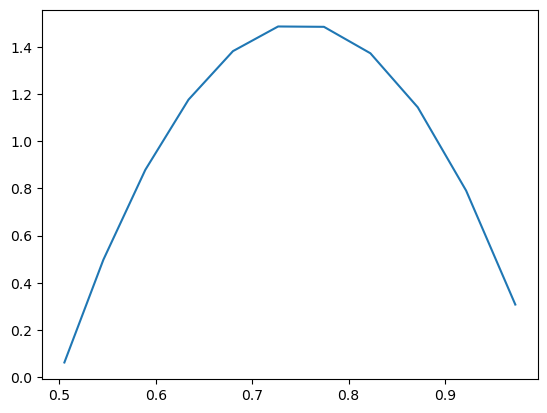

In [242]:
o = np.argsort(nodes_u[boundary_inlet,1])

plt.plot(nodes_u[boundary_inlet,1][o],(4*u_max*(nodes_u[boundary_inlet,1] - 0.5)*(1.0 - nodes_u[boundary_inlet,1])/(0.5**2))[o])
print("HEY! LISTEN! RE = ,", Re)

0.0


C:\Users\user\AppData\Local\Temp\ipykernel_21728\4178856148.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(t_res,np.log(res))


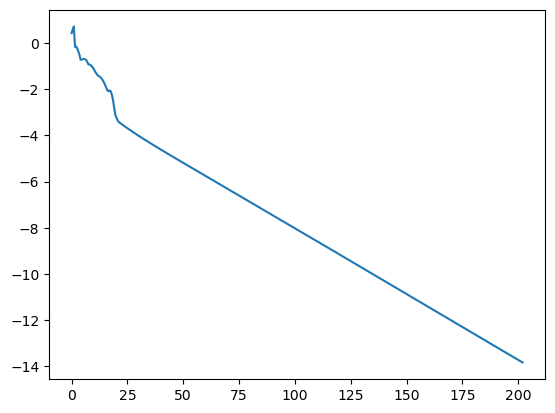

In [243]:
t_res = np.linspace(0,Nt*dt-dt,np.int16(Nt/100))
plt.plot(t_res,np.log(res))
print(res.min())

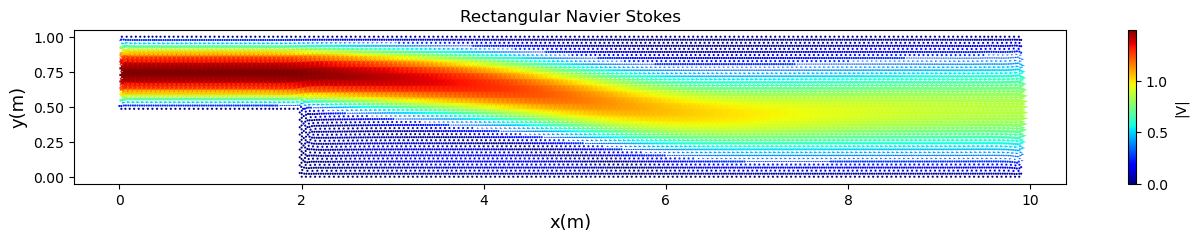

In [244]:
#k = end_index 
vel = np.sqrt(u_new**2 + v_new**2)#np.sqrt(u[base:,k]**2 + v[base:,k]**2)
#v0 = 0.544
plt.figure(figsize=(16,2))

q = plt.quiver(
    nodes_u[:,0],
    nodes_u[:,1],
    u_new,
    v_new,
    vel,
    cmap='jet'#,scale = 40
)

plt.colorbar(q, label='|V|')
plt.title("Rectangular Navier Stokes")
plt.xlabel("x(m)", fontsize = 13)
plt.xscale("linear")
plt.ylabel("y(m)",fontsize = 13)
#plt.axis('equal')
plt.show()


In [245]:
(7.93-7.796169176849001)/7.93 * 100

1.687652246544749

(np.float64(5.762499897679218), np.float64(7.796169176849001))


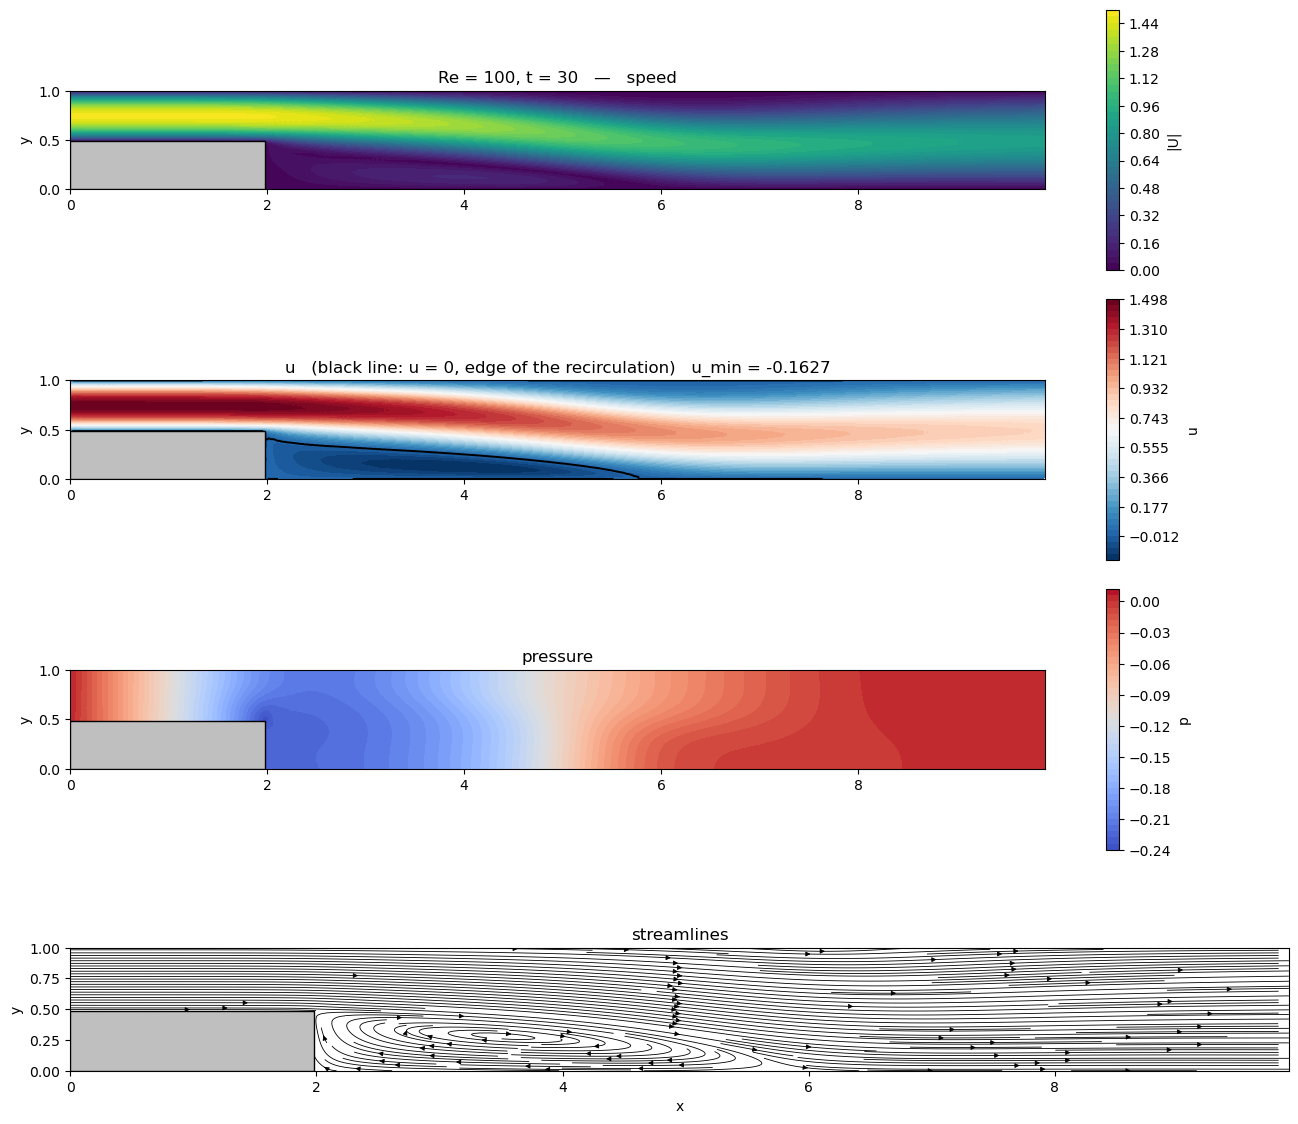

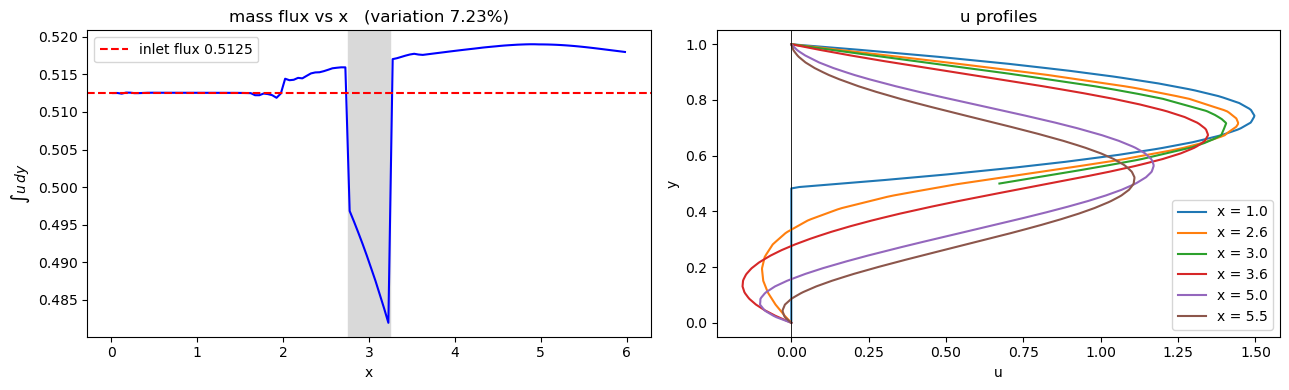

In [246]:
from plot_solution import plot_solution, plot_flux_and_profiles, reattachment

plot_solution(nodes_u, centers_p, u_new, v_new, p_,
              obstacle=(0.0, w_obstacle, 0.0, step), L=L, H=H,
              title='Re = 100, t = 30')
#(np.float64(5.762499897679218), np.float64(7.796169176849001))

plot_flux_and_profiles(nodes_u, u_new)
print(reattachment(nodes_u, u_new, (0.0, w_obstacle, 0.0, step)))